# 🌾 Seasonal Agriculture Performance Analysis

### Data Analysis Project

**Objective:**  
To analyze agricultural performance across different crops, states, seasons, and farming conditions using data analysis and visualization techniques.

---

**Tools & Technologies Used:**
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

## 1. Introduction

Agriculture plays an important role in the economy and livelihood of a large population. Agricultural productivity and profitability depend on several factors such as crop type, season, rainfall, soil conditions, irrigation methods, fertilizer usage, temperature, and pest or disease risks.

This project analyzes a seasonal agriculture performance dataset to identify patterns and relationships between these factors and agricultural outcomes such as yield, production, revenue, cost, and profit.

The analysis uses Python-based data analysis and visualization techniques in Google Colab to generate meaningful insights from the dataset.

## 2. Objectives

The main objectives of this project are:

1. To understand the structure and characteristics of the agricultural dataset.
2. To perform data cleaning and preprocessing.
3. To analyze agricultural performance across different crops and states.
4. To study the effect of seasons and weather conditions on crop yield.
5. To analyze the relationship between rainfall, irrigation, soil nutrients, and yield.
6. To compare agricultural revenue, cost, and profit.
7. To identify factors associated with higher crop productivity.
8. To visualize important patterns and trends using graphs.
9. To derive meaningful insights and conclusions from the analysis.

In [53]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Google Colab
%matplotlib inline

# Set a clean plotting style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [54]:
# Load the dataset

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [55]:
# Display first 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [56]:
# Display last 5 rows

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [57]:
# Number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Dataset Shape:", df.shape)

Number of Rows: 4000
Number of Columns: 28
Dataset Shape: (4000, 28)


In [58]:
# Display all column names

print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, 1):
    print(i, "-", column)

Columns in the dataset:

1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


In [59]:
# General information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [60]:
# Statistical summary of numerical columns

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [61]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3   

In [62]:
# Percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
Farm_ID,0,0.0
State,0,0.0
District,0,0.0
Crop,0,0.0
Season,0,0.0
Farm_Area_Hectares,0,0.0
Rainfall_mm,48,1.2
Avg_Temperature_C,0,0.0
Humidity_pct,0,0.0
Sunlight_Hours_Day,0,0.0


In [63]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [64]:
# Check data types of all columns

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [65]:
# Number of unique values in each column

df.nunique().sort_values()

,0
Season,3
Irrigation_Method,4
Crop,8
State,8
District,10
Seed_Quality_Score,36
Sunlight_Hours_Day,71
Avg_Temperature_C,204
Soil_pH,313
Soil_Moisture_pct,343


In [66]:
# Display unique values for categorical columns

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n", "="*50)
    print(column)
    print(df[column].unique())


Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### 3.1 Distribution of Crops

This analysis shows the number of observations available for each crop in the dataset. It helps us understand which crops are represented more frequently.

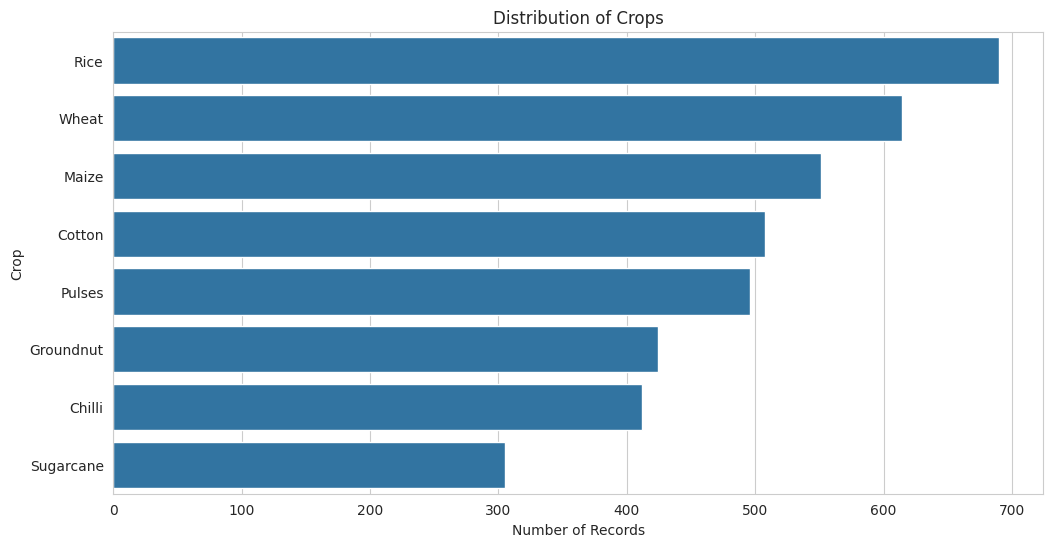

In [67]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='Crop',
    order=df['Crop'].value_counts().index
)

plt.title('Distribution of Crops')
plt.xlabel('Number of Records')
plt.ylabel('Crop')
plt.show()

### 3.2 Distribution by Season

Seasonal conditions can significantly influence agricultural performance. This analysis compares the number of records available for each agricultural season.

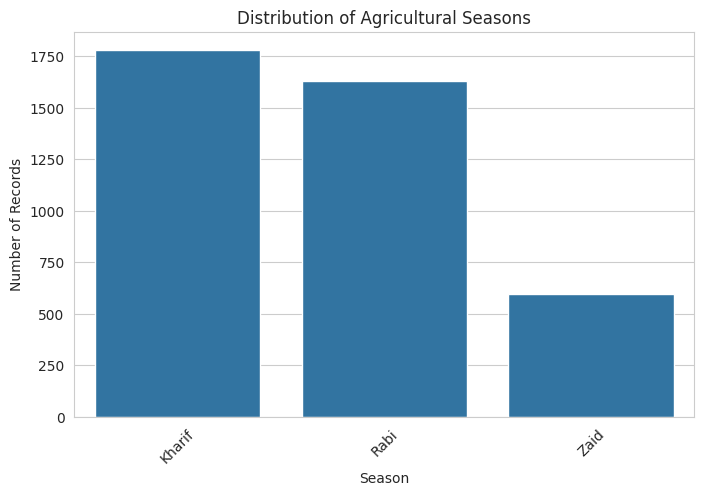

In [68]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Season',
    order=df['Season'].value_counts().index
)

plt.title('Distribution of Agricultural Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

### 3.3 State-wise Distribution

This analysis examines the distribution of agricultural records across different states.

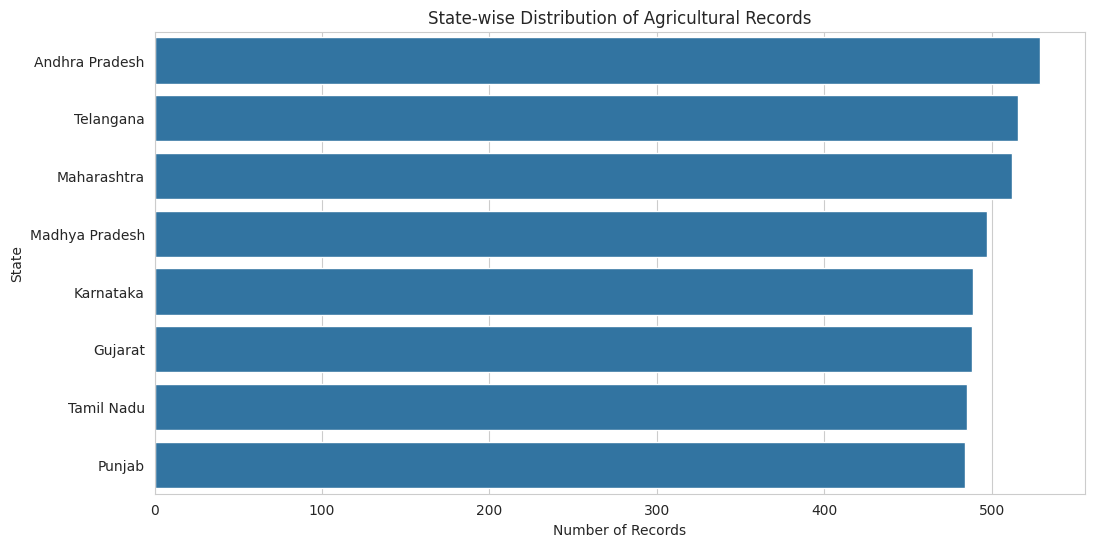

In [69]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='State',
    order=df['State'].value_counts().index
)

plt.title('State-wise Distribution of Agricultural Records')
plt.xlabel('Number of Records')
plt.ylabel('State')
plt.show()

In [70]:
# Check exact column names
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

## 4. Crop Yield Analysis

### 4.1 Average Yield by Crop

Yield is an important indicator of agricultural productivity. This analysis compares the average yield achieved by different crops.

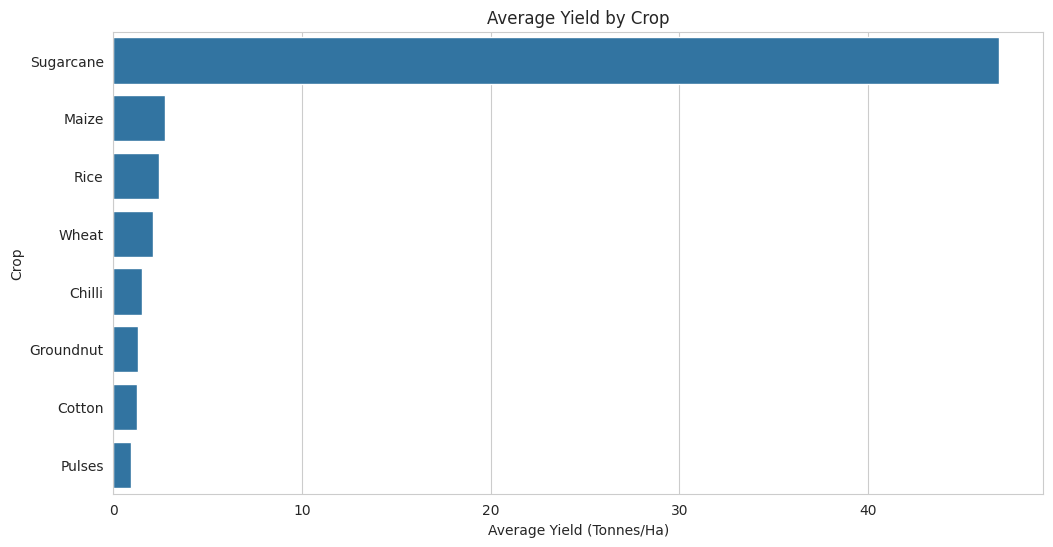

In [71]:
# Average Yield by Crop

avg_yield_crop = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_yield_crop.values,
    y=avg_yield_crop.index
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')
plt.show()

### 4.2 Average Yield by Season

This analysis compares the average crop yield across different seasons to identify which season has the highest agricultural productivity.

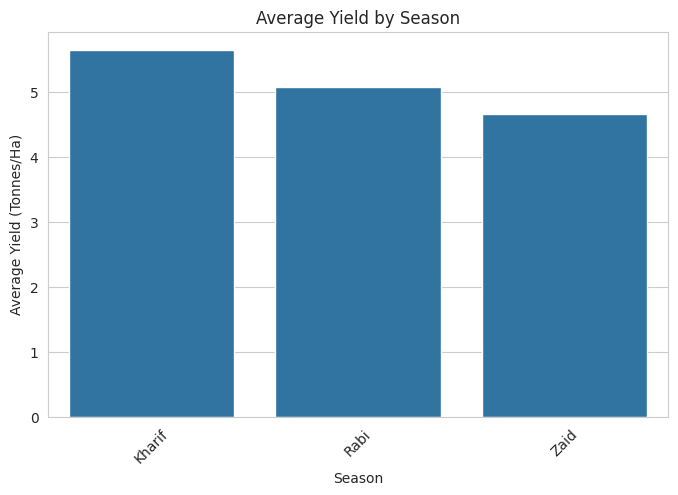

In [72]:
# Average Yield by Season

avg_yield_season = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_yield_season.index,
    y=avg_yield_season.values
)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

## 5. Production Analysis

### 5.1 Total Production by Crop

This analysis compares the total agricultural production generated by different crops.

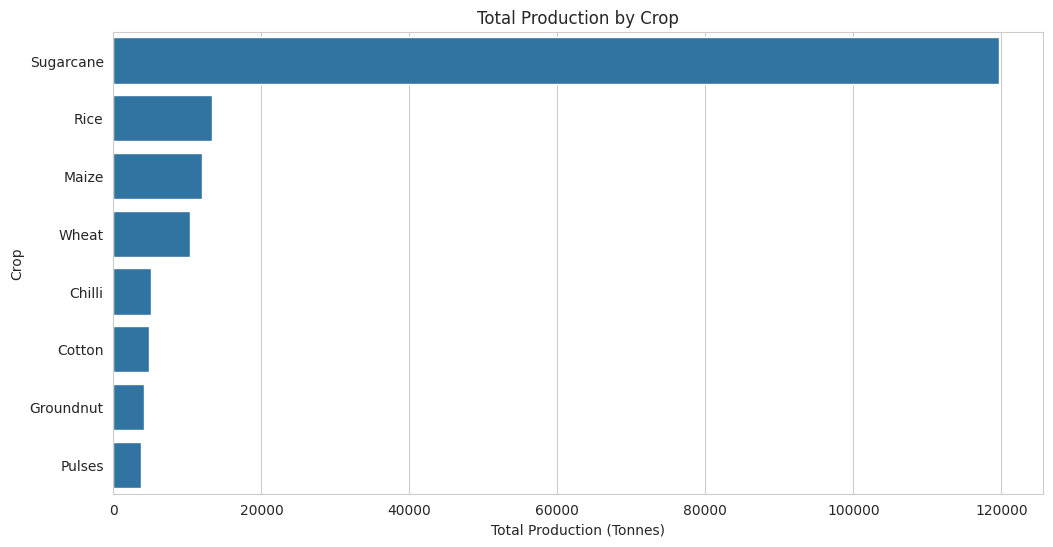

In [73]:
production_crop = (
    df.groupby('Crop')['Production_Tonnes']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=production_crop.values,
    y=production_crop.index
)

plt.title('Total Production by Crop')
plt.xlabel('Total Production (Tonnes)')
plt.ylabel('Crop')
plt.show()

## 6. Revenue, Cost and Profit Analysis

### 6.1 Average Revenue by Crop

Revenue represents the income generated from agricultural production. This analysis compares average revenue across crops.

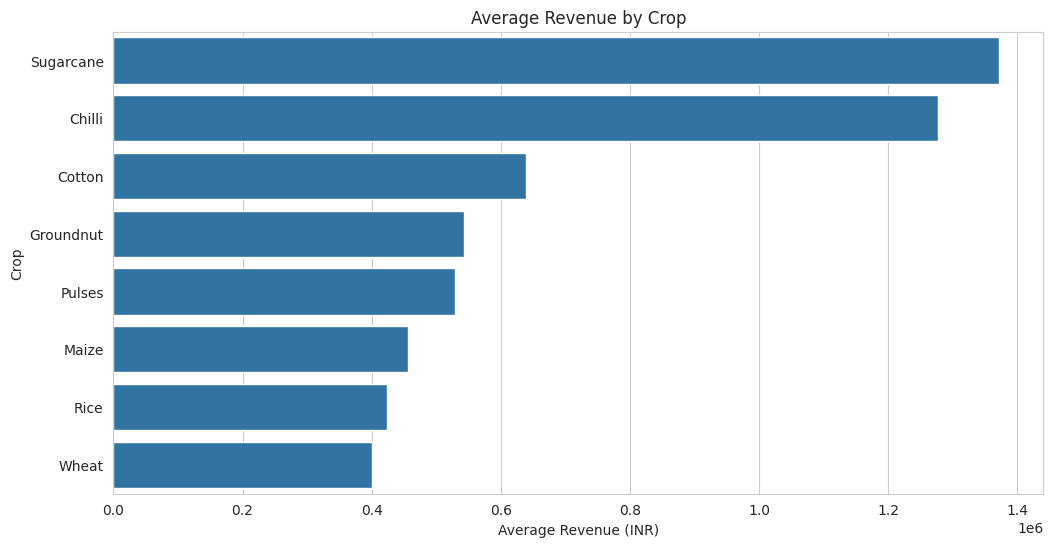

In [74]:
# Average Revenue by Crop

avg_revenue = (
    df.groupby('Crop')['Revenue_INR']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_revenue.values,
    y=avg_revenue.index
)

plt.title('Average Revenue by Crop')
plt.xlabel('Average Revenue (INR)')
plt.ylabel('Crop')
plt.show()

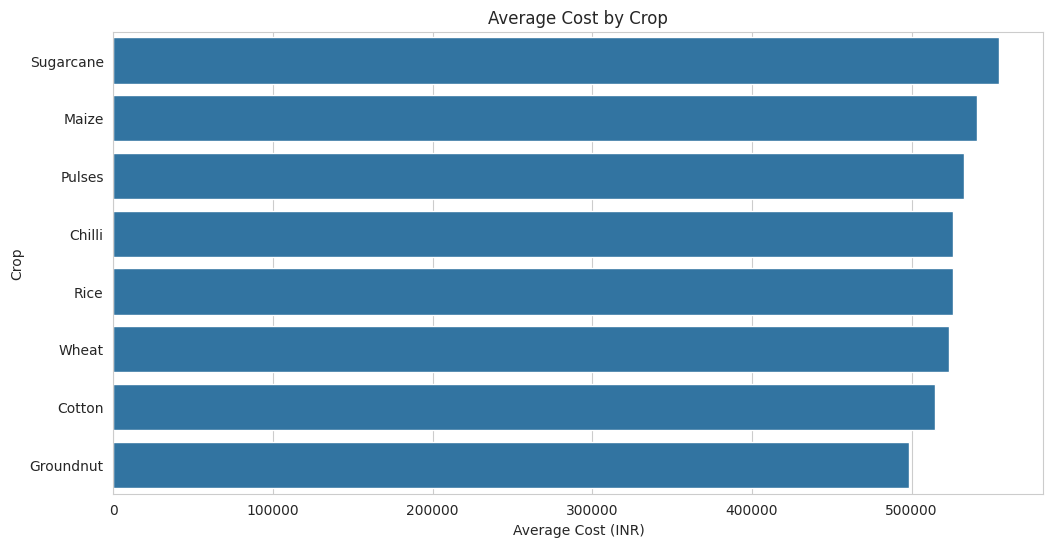

In [75]:
# Average Cost by Crop

avg_cost = (
    df.groupby('Crop')['Total_Cost_INR']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_cost.values,
    y=avg_cost.index
)

plt.title('Average Cost by Crop')
plt.xlabel('Average Cost (INR)')
plt.ylabel('Crop')
plt.show()

### 6.3 Average Profit by Crop

Profit is calculated from agricultural revenue and cost. Comparing profit across crops helps identify economically better-performing crops.

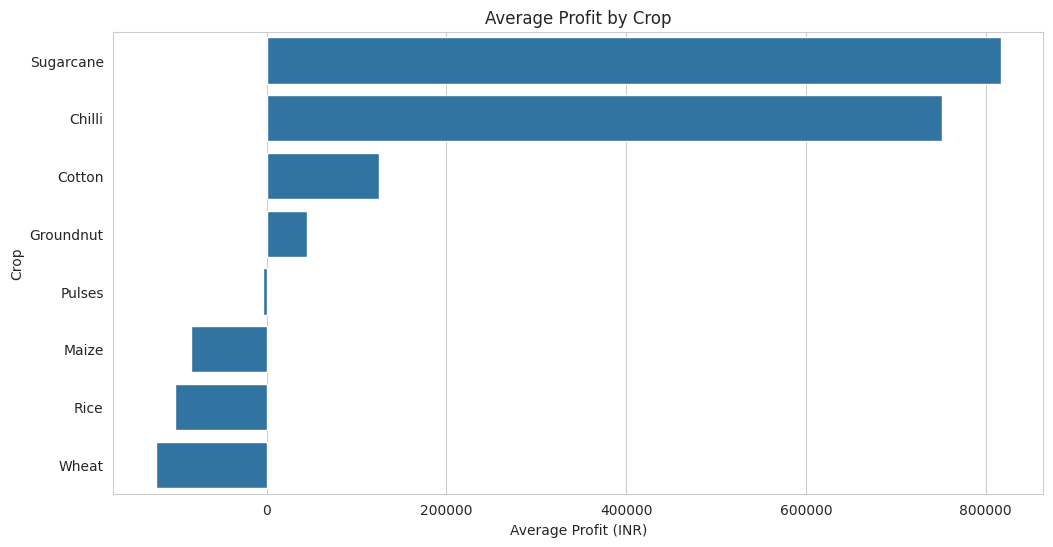

In [76]:
# Average Profit by Crop

avg_profit = (
    df.groupby('Crop')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_profit.values,
    y=avg_profit.index
)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.show()

## 7. Weather and Environmental Analysis

### 7.1 Relationship Between Rainfall and Yield

Rainfall is an important environmental factor affecting crop growth. A scatter plot is used to examine the relationship between rainfall and crop yield.

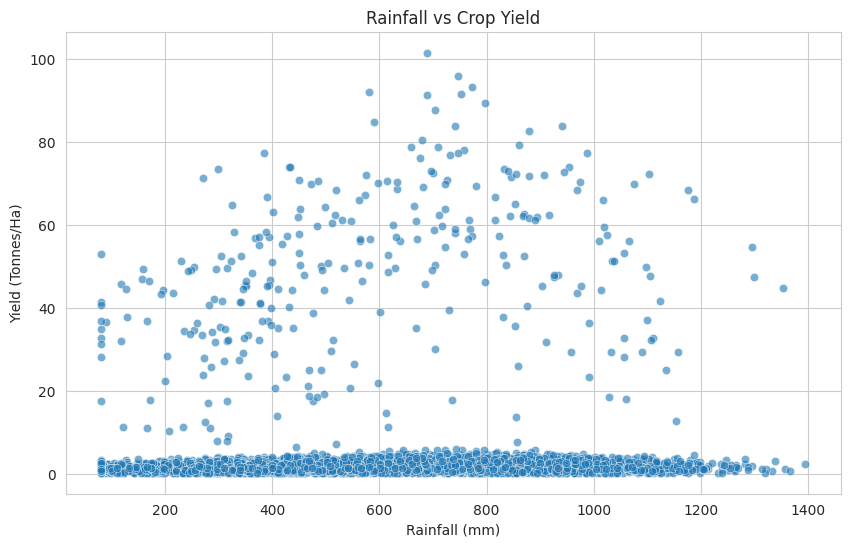

In [77]:
# Rainfall vs Yield

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

# Temperature vs Yield

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

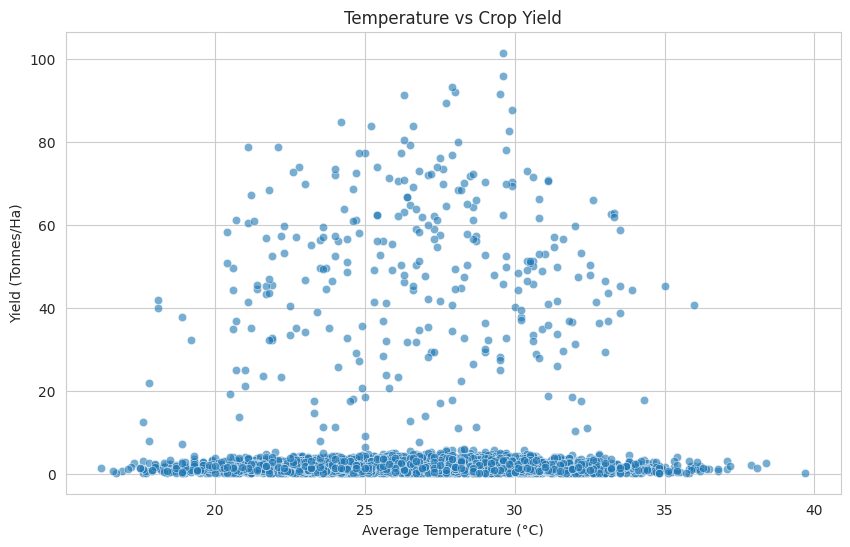

In [78]:
# Temperature vs Yield

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### 8.1 Yield by Irrigation Method

Different irrigation methods may influence crop productivity. This analysis compares the average yield associated with each irrigation method.

In [79]:
# Check irrigation methods

df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


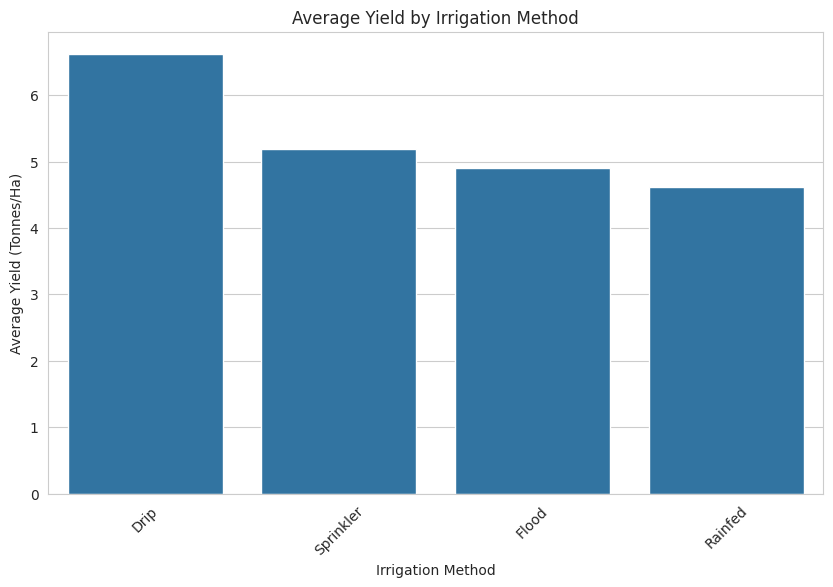

In [80]:
# Average Yield by Irrigation Method

irrigation_yield = (
    df.groupby('Irrigation_Method')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

## 9. Soil Nutrient Analysis

### 9.1 Relationship Between Nitrogen and Yield

Nitrogen is an essential nutrient for crop growth. This analysis examines whether nitrogen availability is associated with crop yield.

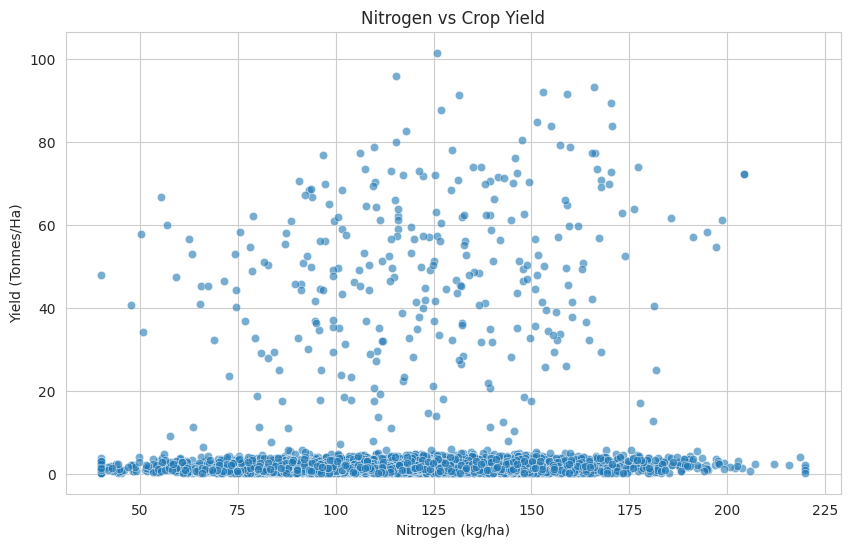

In [81]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Nitrogen_kg_ha',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Nitrogen vs Crop Yield')
plt.xlabel('Nitrogen (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

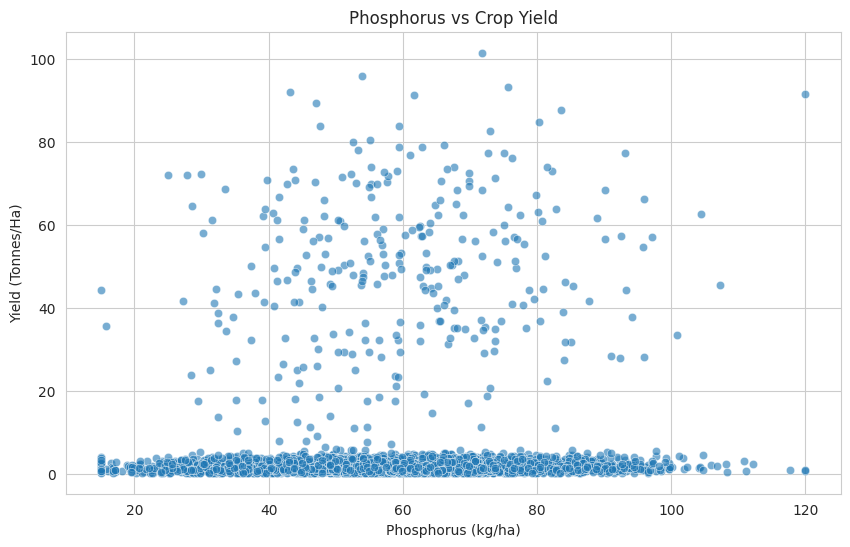

In [82]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Phosphorus_kg_ha',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Phosphorus vs Crop Yield')
plt.xlabel('Phosphorus (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

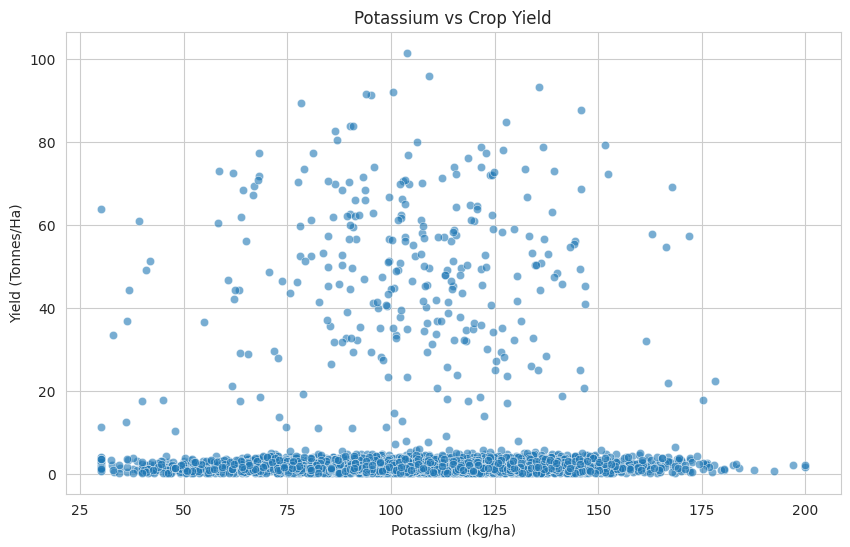

In [83]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Potassium_kg_ha',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Potassium vs Crop Yield')
plt.xlabel('Potassium (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## 10. Water Usage and Efficiency Analysis

### 10.1 Relationship Between Water Usage and Yield

Water availability is an important factor in agricultural productivity. This analysis examines the relationship between water usage and crop yield.

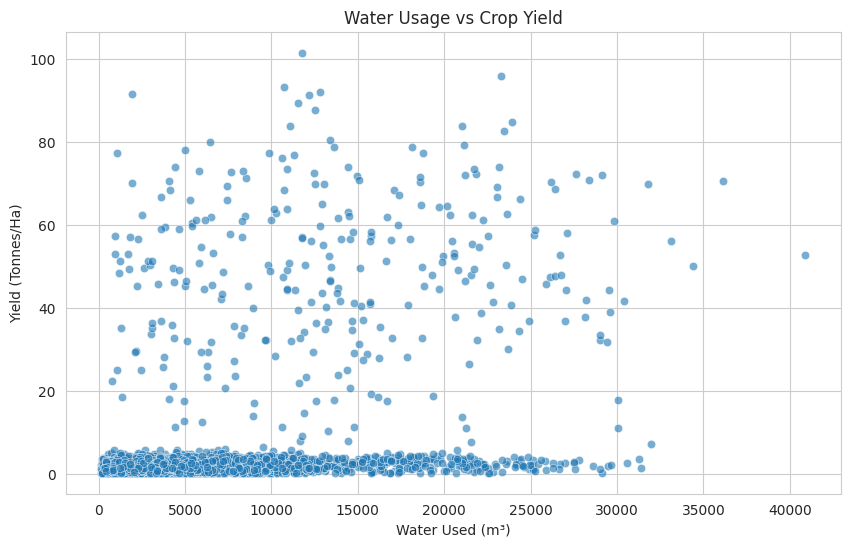

In [84]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Water Usage vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### 10.2 Water Efficiency by Crop

Water efficiency indicates how effectively water resources are converted into agricultural output. This analysis compares water-use efficiency across crops.

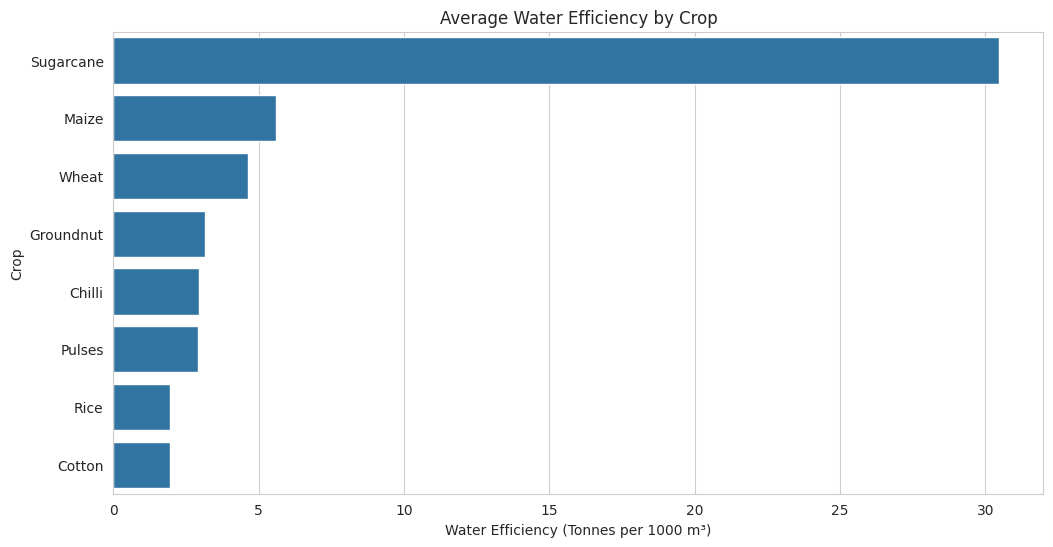

In [85]:
water_efficiency = (
    df.groupby('Crop')['Water_Efficiency_t_per_1000m3']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=water_efficiency.values,
    y=water_efficiency.index
)

plt.title('Average Water Efficiency by Crop')
plt.xlabel('Water Efficiency (Tonnes per 1000 m³)')
plt.ylabel('Crop')
plt.show()

## 11. Disease and Pest Risk Analysis

### 11.1 Average Disease/Pest Risk by Crop

Disease and pest attacks can negatively affect agricultural productivity. This analysis compares the average disease and pest risk across different crops.

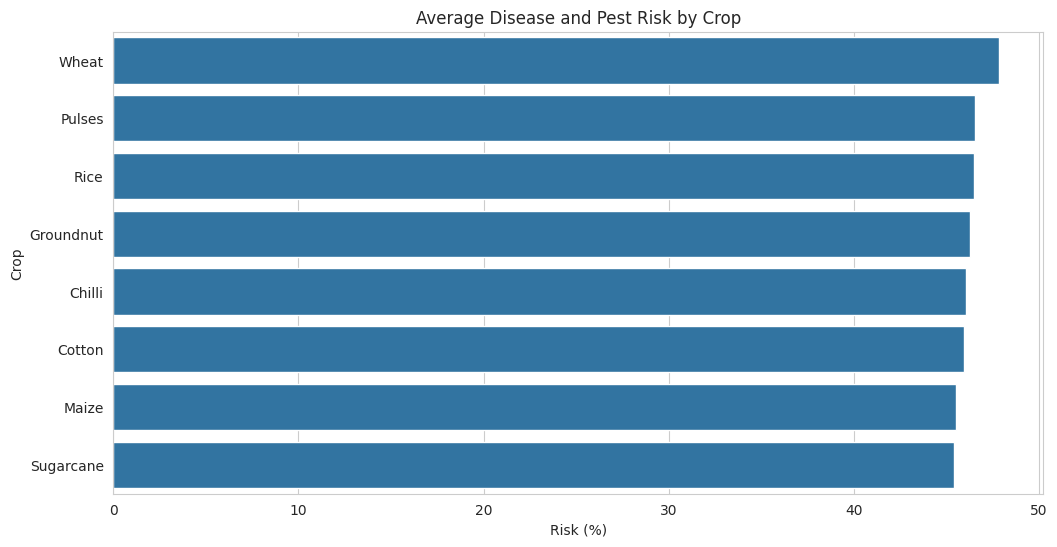

In [86]:
risk_crop = (
    df.groupby('Crop')['Disease_Pest_Risk_pct']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=risk_crop.values,
    y=risk_crop.index
)

plt.title('Average Disease and Pest Risk by Crop')
plt.xlabel('Risk (%)')
plt.ylabel('Crop')
plt.show()

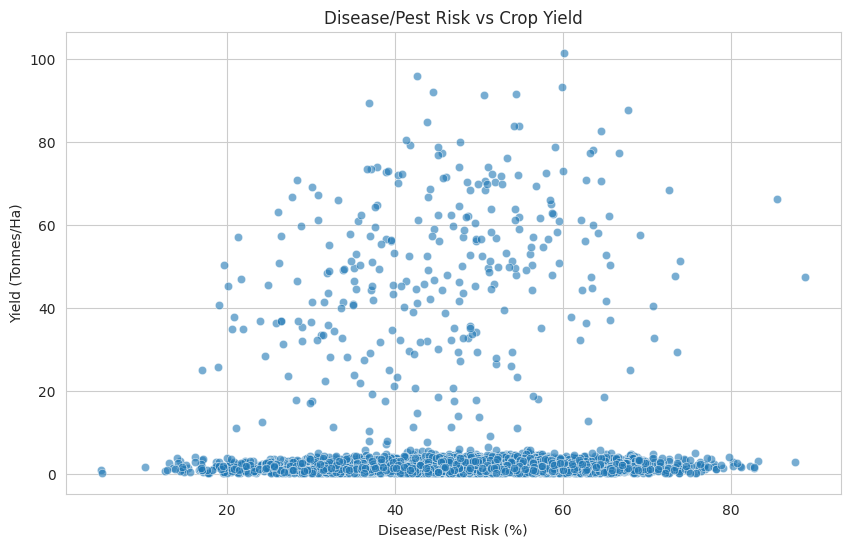

In [87]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Disease/Pest Risk vs Crop Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## 12. Correlation Analysis

Correlation analysis is used to understand the strength and direction of relationships between numerical variables in the dataset.

A correlation value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship. A value close to 0 indicates a weak or no linear relationship.

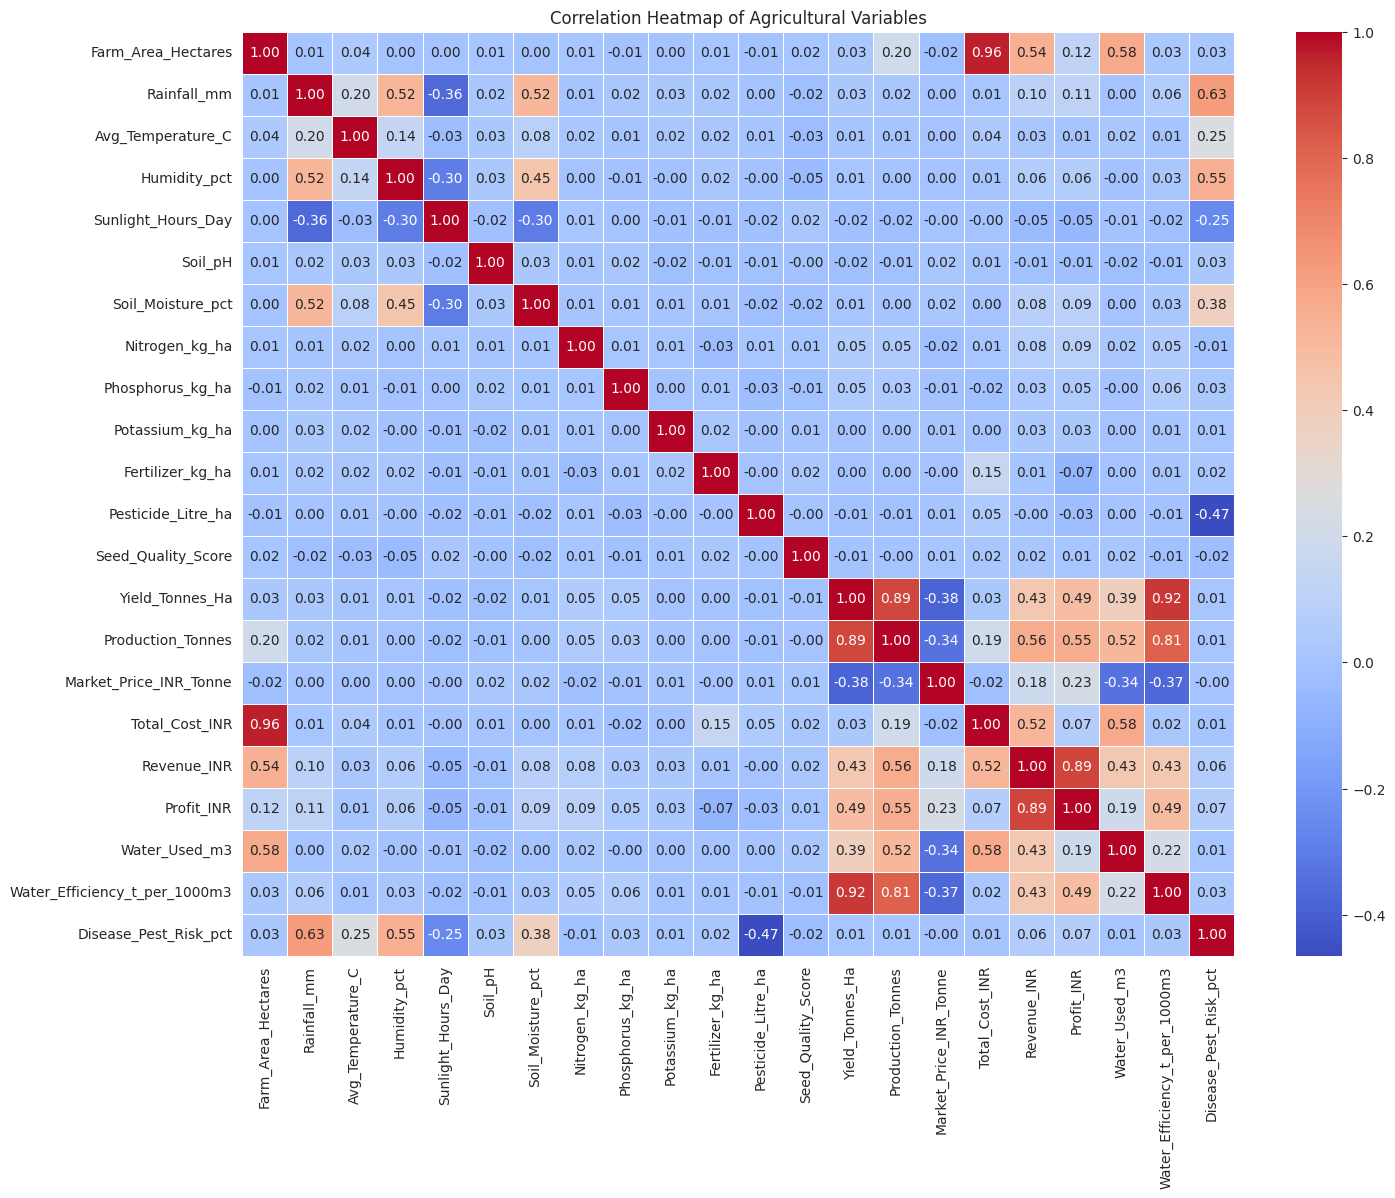

In [88]:
# Select numerical columns

numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Agricultural Variables')
plt.show()

In [89]:
yield_correlation = (
    correlation_matrix['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

yield_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.915438
Production_Tonnes,0.885171
Profit_INR,0.489822
Revenue_INR,0.433648
Water_Used_m3,0.388653
Nitrogen_kg_ha,0.053867
Phosphorus_kg_ha,0.047821
Rainfall_mm,0.030853
Total_Cost_INR,0.030814


## 12.1 Interpretation of Correlation with Yield

The correlation analysis shows that Water Efficiency has the strongest positive correlation with Yield, with a correlation coefficient of 0.9154.

Production also has a strong positive correlation with Yield (0.8852). Profit and Revenue show moderate positive correlations with Yield, while Market Price has a moderate negative correlation with Yield (-0.3843).

Most environmental and input-related variables such as rainfall, temperature, soil moisture, nitrogen, phosphorus, potassium, fertilizer usage, and disease/pest risk show weak linear correlations with yield in this dataset.

It is important to note that correlation indicates association and does not necessarily imply causation.

### 12.2 Factors Correlated with Crop Yield

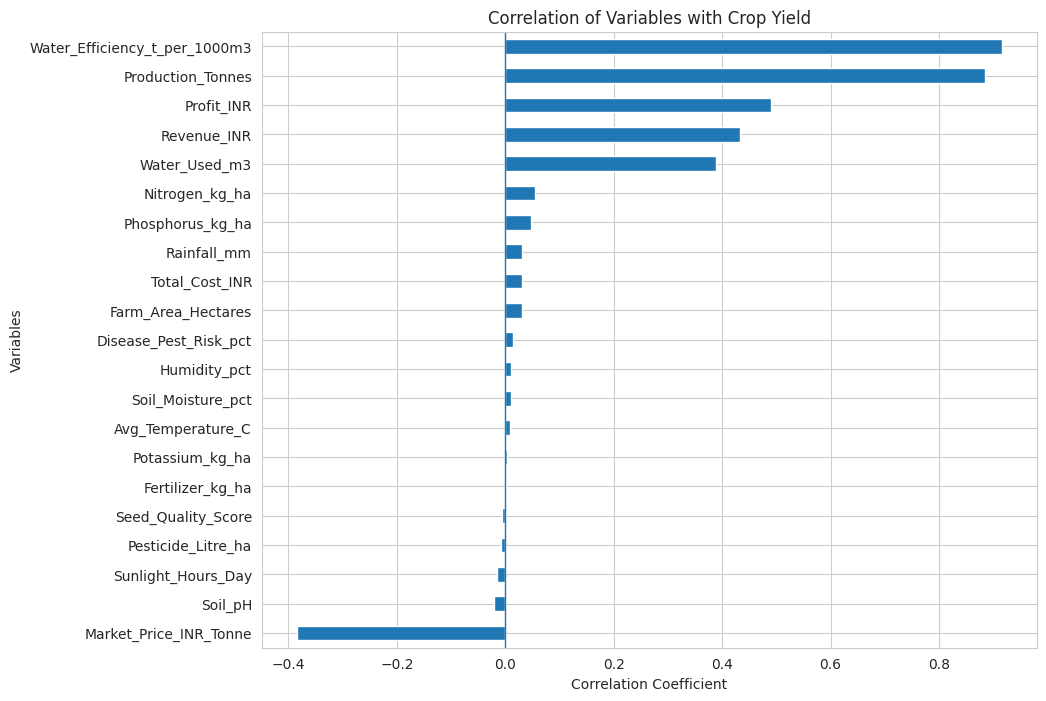

In [90]:
# Remove Yield itself and sort correlations

yield_corr = correlation_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha')
yield_corr = yield_corr.sort_values()

plt.figure(figsize=(10, 8))

yield_corr.plot(kind='barh')

plt.title('Correlation of Variables with Crop Yield')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variables')

plt.axvline(0, linewidth=1)

plt.show()

## 13. Top Performing Crops

### 13.1 Top Crops by Average Yield

This analysis identifies the crops with the highest average yield in tonnes per hectare.

In [91]:
top_yield_crops = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

top_yield_crops

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.938746
Maize,2.717130
Rice,2.439413
Wheat,2.109216
Chilli,1.540344
Groundnut,1.317924
Cotton,1.225734
Pulses,0.918198


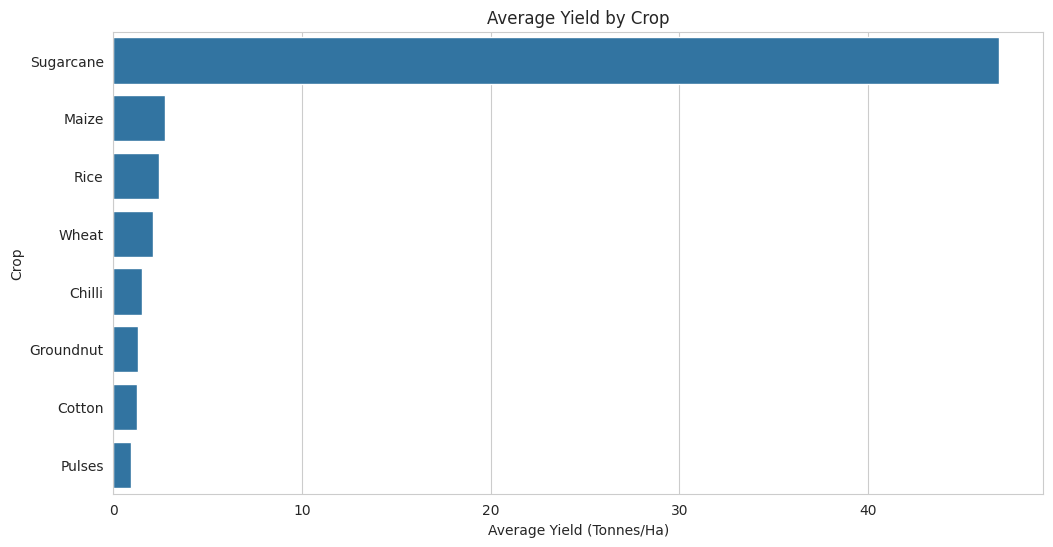

In [92]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_yield_crops.values,
    y=top_yield_crops.index
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.show()

### 13.2 Top Crops by Average Profit

This analysis identifies the crops generating the highest average profit.

In [93]:
top_profit_crops = (
    df.groupby('Crop')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

top_profit_crops

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


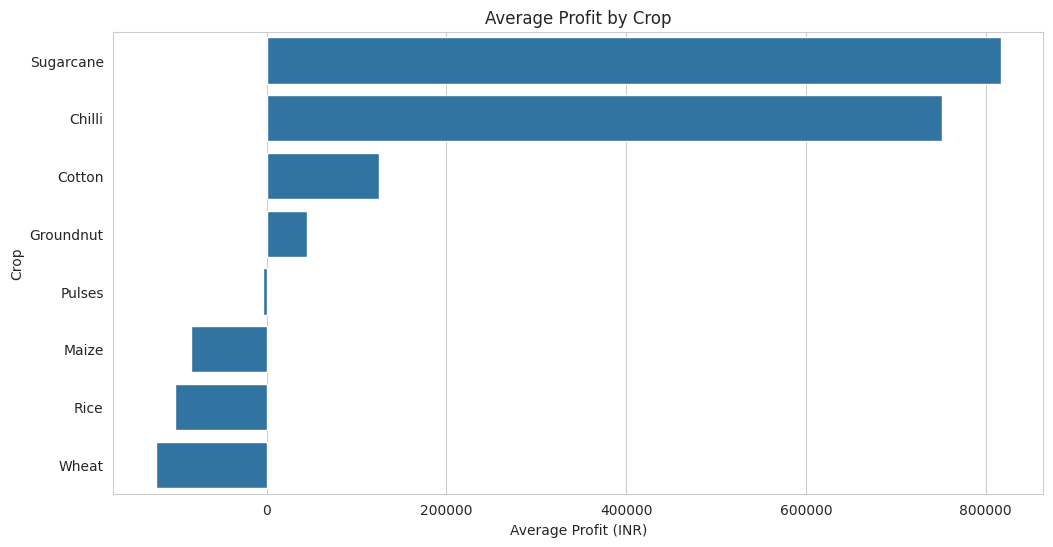

In [94]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_profit_crops.values,
    y=top_profit_crops.index
)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

plt.show()

## 14. State-wise Agricultural Performance

### 14.1 Average Yield by State

This analysis compares the average agricultural yield across different states represented in the dataset.

In [95]:
state_yield = (
    df.groupby('State')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

state_yield

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.734493
Gujarat,5.699586
Telangana,5.076810
Maharashtra,5.030333
Madhya Pradesh,5.029654
Tamil Nadu,4.901247
Andhra Pradesh,4.650781


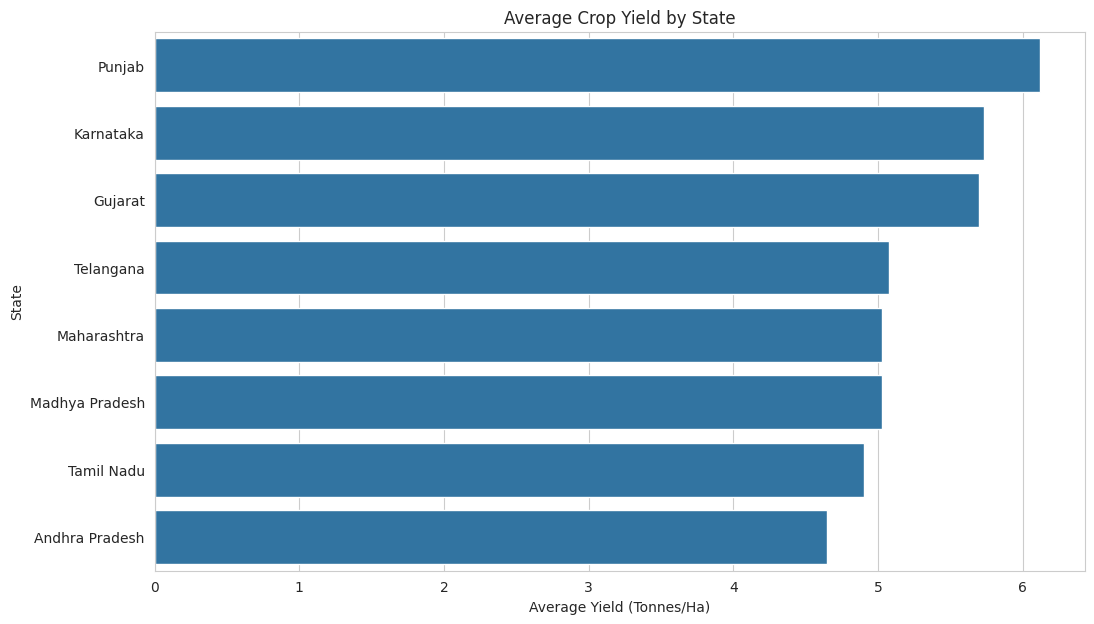

In [96]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_yield.values,
    y=state_yield.index
)

plt.title('Average Crop Yield by State')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('State')

plt.show()

## 15. Seasonal Performance Analysis

### 15.1 Average Profit by Season

This analysis compares the average profit generated during different agricultural seasons.

In [97]:
season_profit = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


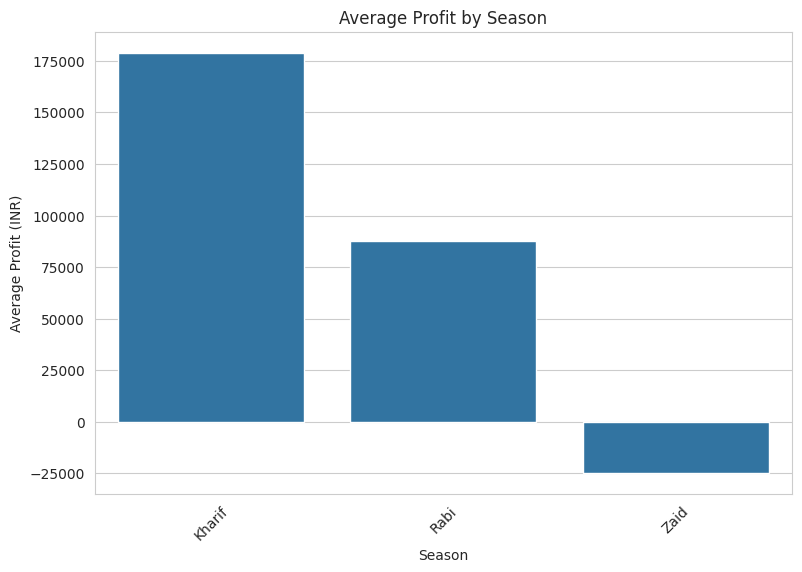

In [98]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.show()

## 16. Key Insights

Based on the exploratory data analysis, the following key insights were identified:

1. Water efficiency has a very strong positive association with crop yield, with a correlation coefficient of approximately 0.92.

2. Production has a strong positive relationship with yield, with a correlation coefficient of approximately 0.89.

3. Profit and revenue show moderate positive relationships with crop yield.

4. Market price shows a moderate negative relationship with yield, with a correlation coefficient of approximately -0.38.

5. Most environmental factors such as rainfall, temperature, humidity, and soil moisture show relatively weak linear relationships with yield in this dataset.

6. The performance of crops varies across different states and agricultural seasons.

7. Different irrigation methods are associated with different levels of average crop yield.

8. Crop profitability varies considerably, indicating that some crops may provide better economic returns than others.

9. Disease and pest risk varies across crops and can be considered an important factor when evaluating agricultural performance.

10. Overall, the analysis demonstrates that agricultural performance depends on multiple interacting factors, including productivity, resource efficiency, environmental conditions, and economic factors.


## 17. Recommendations

Based on the analysis, the following recommendations can be made:

1. Farmers should focus on improving water-use efficiency to optimize agricultural productivity.

2. Efficient irrigation methods should be encouraged to reduce unnecessary water consumption.

3. Crop selection should consider both yield and profitability rather than yield alone.

4. Farmers should monitor disease and pest risks regularly to reduce potential crop losses.

5. Soil nutrient management should be based on the specific requirements of individual crops.

6. Agricultural decisions should consider seasonal conditions and regional differences.

7. Data-driven agricultural practices can help farmers improve productivity while using resources more efficiently.

8. Further analysis using larger datasets and advanced predictive models could help identify the factors that most strongly influence crop performance.

## 18. Conclusion

The Seasonal Agriculture Performance Analysis provided useful insights into crop productivity, resource utilization, environmental conditions, and economic performance.

The analysis showed a very strong positive association between water efficiency and crop yield, while production also showed a strong relationship with yield. Profit and revenue demonstrated moderate positive relationships with yield, whereas market price showed a moderate negative relationship.

The study also highlighted differences in agricultural performance across crops, states, seasons, and irrigation methods.

Overall, data analysis and visualization can provide valuable support for understanding agricultural performance and making more informed decisions regarding crop selection, irrigation, resource management, and profitability.

The findings demonstrate the importance of using agricultural data to promote efficient resource utilization and improve overall farm performance.

## 19. Limitations

The following limitations should be considered:

1. The analysis is based only on the variables available in the provided dataset.

2. Correlation analysis identifies relationships between variables but does not establish causation.

3. External factors such as government policies, labor availability, market demand, extreme weather events, and farmer experience are not considered.

4. The results may not represent all agricultural regions or farming conditions.

5. Further analysis using larger and more diverse datasets would provide more generalizable results.

## 20. Final Project Summary

This project analyzed seasonal agricultural performance using Python and various data analysis and visualization techniques.

The analysis covered:

- Dataset exploration and preprocessing
- Crop and state distribution
- Seasonal analysis
- Crop yield analysis
- Production analysis
- Revenue, cost, and profit analysis
- Weather and environmental analysis
- Irrigation analysis
- Soil nutrient analysis
- Water usage and efficiency analysis
- Disease and pest risk analysis
- Correlation analysis
- Identification of top-performing crops and states

The project demonstrates how data analysis can be used to transform agricultural data into meaningful insights that can support better decision-making and resource management.

In [99]:
print("=" * 60)
print("       SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("=" * 60)

print("\nDataset Shape:", df.shape)

print("\nNumber of Crops:", df['Crop'].nunique())
print("Number of States:", df['State'].nunique())
print("Number of Seasons:", df['Season'].nunique())

print("\nAverage Yield:",
      round(df['Yield_Tonnes_Ha'].mean(), 2), "Tonnes/Ha")

print("Average Production:",
      round(df['Production_Tonnes'].mean(), 2), "Tonnes")

print("Average Revenue: ₹",
      round(df['Revenue_INR'].mean(), 2))

print("Average Cost: ₹",
      round(df['Total_Cost_INR'].mean(), 2))

print("Average Profit: ₹",
      round(df['Profit_INR'].mean(), 2))

print("\nHighest Average Yield Crop:",
      df.groupby('Crop')['Yield_Tonnes_Ha'].mean().idxmax())

print("Highest Average Profit Crop:",
      df.groupby('Crop')['Profit_INR'].mean().idxmax())

print("Best Average Yield State:",
      df.groupby('State')['Yield_Tonnes_Ha'].mean().idxmax())

print("Best Average Profit Season:",
      df.groupby('Season')['Profit_INR'].mean().idxmax())

print("\n" + "=" * 60)
print("                 END OF ANALYSIS")
print("=" * 60)

       SEASONAL AGRICULTURE PERFORMANCE ANALYSIS

Dataset Shape: (4000, 28)

Number of Crops: 8
Number of States: 8
Number of Seasons: 3

Average Yield: 5.27 Tonnes/Ha
Average Production: 43.25 Tonnes
Average Revenue: ₹ 637860.05
Average Cost: ₹ 526303.58
Average Profit: ₹ 111556.46

Highest Average Yield Crop: Sugarcane
Highest Average Profit Crop: Sugarcane
Best Average Yield State: Punjab
Best Average Profit Season: Kharif

                 END OF ANALYSIS


## 20.1 Final Findings

The analysis of 4,000 agricultural records across 8 crops, 8 states, and 3 seasons produced the following findings:

- The dataset contains 4,000 records and 28 variables.
- The average crop yield is 5.27 tonnes per hectare.
- The average production is 43.25 tonnes.
- The average revenue is ₹637,860.05.
- The average total cost is ₹526,303.58.
- The average profit is ₹111,556.46.
- Sugarcane has the highest average yield among the crops analyzed.
- Sugarcane also has the highest average profit.
- Punjab has the highest average crop yield among the states in the dataset.
- Kharif is the season with the highest average profit.
- Water efficiency has the strongest positive correlation with yield, with a correlation coefficient of 0.9154.
- Production also has a strong positive correlation with yield, with a correlation coefficient of 0.8852.
- Profit and revenue have moderate positive relationships with yield.
- Market price has a moderate negative correlation with yield (-0.3843).

## 21. Overall Conclusion

The Seasonal Agriculture Performance Analysis successfully examined agricultural productivity, resource utilization, environmental factors, and economic performance using a dataset containing 4,000 records and 28 variables.

The analysis revealed significant differences in crop performance, profitability, state-wise productivity, and seasonal performance. Sugarcane emerged as the crop with the highest average yield and average profit, while Punjab recorded the highest average yield among the states. Kharif showed the highest average profit among the three seasons analyzed.

Correlation analysis showed that water efficiency had the strongest positive association with crop yield, followed by total production. Profit and revenue also showed positive relationships with yield, while market price showed a moderate negative relationship.

Overall, the project demonstrates how Python-based data analysis and visualization can be used to identify patterns in agricultural data and support data-driven decision-making related to crop selection, resource management, irrigation, productivity, and profitability.

## 22. Recommendations

Based on the findings of this analysis, the following recommendations are suggested:

1. Improve water-use efficiency through efficient irrigation practices.
2. Consider both crop productivity and profitability when selecting crops.
3. Monitor crop performance across different seasons and regions.
4. Use appropriate soil nutrient management practices based on crop requirements.
5. Monitor disease and pest risks to minimize potential production losses.
6. Encourage data-driven agricultural planning for better resource utilization.
7. Conduct further analysis using larger datasets and predictive machine learning models to forecast crop yield and profitability.